In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    get_ipython().run_line_magic(
        'cd',
        '..//..//content//drive//MyDrive//Colab-Notebooks//HY-673-Tutorials//Tutorial-6'
    )
except:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab-Notebooks/HY-673-Tutorials/Tutorial-6


# <u>Building a Transformer with PyTorch</u>

In the previous notebook, we used PyTorch's built-in `nn.Transformer` module to solve a simple copy task. In this notebook, we will solve the **same exact task**, but this time we will manually construct the Transformer architecture from its individual components.

In [ ]:
!pip install torchinfo

In [ ]:
import torch as tc
import torch.nn as nn
from tqdm import tqdm
from time import perf_counter
from torchinfo import summary
import matplotlib.pyplot as plt

bar = '-'*64
seed = 42
tc.manual_seed(seed)
device = 'cuda' if tc.cuda.is_available() else 'cpu'
print(f"using {device}")

using cpu


### <u>Multi-Head Attention Layer</u>

<img src="fig/multihead.png" width="800">
<img src="https://drive.google.com/uc?export=view&id=1I1cP0o8Yr7cvuS-AvOoF8AeKeMTko75c" width="800">

The Multi-Head Attention mechanism allows the model to compute attention between different positions in a sequence and to capture different types of relationships between tokens. The Transformer uses multiple attention heads so that different subspaces of the input representation can be attended to in parallel. Revisiting our theory document for this tutorial, with $h$ number of heads we have to implement the following:

\begin{equation}
\text{MultiHead} = \text{Concatenate}\left(O^{(1)}, \ O^{(2)}, \ \dots, \ O^{(h)} \right)\cdot W_O,
\tag{1}
\end{equation}

\begin{equation}
O^{(i)} = S^{(i)} \cdot V^{(i)} =
\text{softmax}\left(
\frac{Q^{(i)} \cdot \left(K^{(i)}\right)^\intercal}{\sqrt{d_k}}
\right)\cdot V^{(i)},
\tag{2}
\end{equation}

\begin{equation}
Q^{(i)} = W_Q^{(i)} \cdot X, \qquad
K^{(i)} = W_K^{(i)} \cdot X, \qquad
V^{(i)} = W_V^{(i)} \cdot X.
\tag{3}
\end{equation}

#### <u>Splitting and Combining for Multi-Head Attention</u>

In the original Transformer model, the dimension $d_\text{model}$ is divided among $h$ attention heads. Therefore, the dimensionality of each head becomes $d_k = d_v = d_\text{model} / h$.

In the code below, however, we first project the input $X$ into matrices of dimension $d_\text{model}$ for $Q$, $K$, and $V$. This is why the linear layers `W_Q`, `W_K`, and `W_V` all map from $d_\text{model}$ to $d_\text{model}$. The actual split into multiple heads happens afterwards, by reshaping the resulting tensors.

Similarly, although each attention head is conceptually associated with its own projection matrices, we do not define separate linear layers for each head explicitly. Instead, we apply one projection over the full input dimension and then split the result across heads. In this way, each head operates on a different slice of the projected representation, which is equivalent to assigning different learned projections to different heads.

After attention is computed independently for each head, the outputs are concatenated and projected once more through the output matrix $W_O$.

We can implement the above operations in PyTorch as follows:

In [ ]:
class MultiHeadAttention(nn.Module):
    """Splits the input into multiple attention heads,
    applies attention to each head, and then combines the results."""
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, \
        "d_model must be divisible by num_heads"

        # Initialize dimensions:
        self.d_model = d_model      # Model's dimension
        self.num_heads = num_heads  # Number of attention heads
        self.d_k = tc.tensor(
            d_model // num_heads, device=device
        ) # Dimension of each head's key, query, and value

        # Linear layers for transforming inputs:
        self.W_Q = nn.Linear(d_model, d_model) # Query  transformation
        self.W_K = nn.Linear(d_model, d_model) # Key    transformation
        self.W_V = nn.Linear(d_model, d_model) # Value  transformation
        self.W_O = nn.Linear(d_model, d_model) # Output transformation

    def scaled_dot_product_attention(self, q, k, v, mask=None):
        # Calculate attention scores Q*K^T/sqrt(d_k):
        attn_scores = tc.matmul(q, k.transpose(-2, -1)) / tc.sqrt(self.d_k)

        # Apply mask if provided
        # (useful for preventing attention to certain parts like padding):
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask==0, value=-1e9)

        # Softmax is applied row-wise to obtain the attention matrix S:
        s = tc.softmax(attn_scores, dim=-1)

        # Multiply S by the values to obtain the output:
        return tc.matmul(s, v)

    def split_heads(self, x):
        """Reshapes the input x from
        (batch_size, seq_len, d_model) --> to
        (batch_size, num_heads, seq_length, d_k).
        It enables the model to process multiple attention heads
        allowing for parallel computation."""
        batch_size_, seq_length, d_model = x.size()
        return (
          x.view(batch_size_, seq_length, self.num_heads, self.d_k)
          .transpose(1, 2)
        )

    def combine_heads(self, x):
        """Reshapes the input x from
        (batch_size, num_heads, seq_length, d_k) --> to
        (batch_size, seq_len, d_model).
        That is, back to the original shape."""
        # Combine the multiple heads back to original shape:
        batch_size_, _, seq_length, d_k = x.size()
        return (
          x.transpose(1, 2).contiguous()
          .view(batch_size_, seq_length, self.d_model)
        )

    def forward(self, q, k, v, mask=None):
        # Apply the linear transformations and split heads:
        q = self.split_heads(self.W_Q(q))
        k = self.split_heads(self.W_K(k))
        v = self.split_heads(self.W_V(v))
        # Perform scaled dot-product (self) attention:
        o = self.scaled_dot_product_attention(q, k, v, mask)
        # Combine heads and apply the output transformation:
        return self.W_O(self.combine_heads(o))

### <u>Position-Wise Feed-Forward Network (FFN)</u>
Next, let us define the Feed Forward Network (FFN) block. It is a position-wise feed-forward neural network that consists of two linear layers with a ReLU activation function in between:

\begin{equation}
  \text{FFN}(X) = \text{ReLU}\left(X \cdot W_1 + b1\right)\cdot W_2 + b2.
  \tag{4}
\end{equation}

In the context of transformer models, this feed-forward network is applied to each position separately and identically. It helps in transforming the features learned by the attention mechanisms within the transformer, acting as an additional processing step for the attention outputs:

In [ ]:
class PositionWiseFeedForward(nn.Module):
    """Implementation of the Feed Forward Network (FFN block)."""
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

### <u>Positional Encoding Layer</u>

Same as in the previous notebook:

In [ ]:
loge4 = 4*tc.log(tc.tensor(10))

class PositionalEncoding(nn.Module):
    """Using sine and cosine functions of different frequencies
    to generate the positional encoding."""
    def __init__(self, d_model, max_seq_length):
        super(PositionalEncoding, self).__init__()
        position = tc.arange(0, max_seq_length, dtype=tc.float).unsqueeze(1)
        div_term = tc.exp(tc.arange(0, d_model, 2).float() * -(loge4 / d_model))
        pe = tc.zeros(max_seq_length, d_model)
        pe[:, 0::2] = tc.sin(position * div_term)
        pe[:, 1::2] = tc.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

### <u>Encoder Layer</u>

<img src="fig/encoder.png" width="400">
<img src="https://drive.google.com/uc?export=view&id=1OjQM6_PSrIwQb5WEQeZgBF_q-hgsHYxf" width="400">

The EncoderLayer class defines a single layer of the transformer's encoder. It encapsulates a multi-head self-attention mechanism followed by position-wise FFN, with residual connections, layer normalization, and dropout. These components together allow the encoder to capture complex relationships in the input data and transform them into a useful representation for downstream tasks. Typically, multiple such encoder layers are stacked to form the complete encoder part of a transformer model:

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        o = self.self_attn(q=x, k=x, v=x, mask=mask)
        x = self.norm1(x + self.dropout(o))
        ffn_output = self.feed_forward(x)
        return self.norm2(x + self.dropout(ffn_output))

### <u>Decoder Layer</u>

<img src="fig/decoder.png" width="400">
<img src="https://drive.google.com/uc?export=view&id=1JZWyKgGzgzUThKLmT-GubslKZcRUu7v5" width="400">

The DecoderLayer class defines a single layer of the transformer's decoder. It consists of a multi-head self-attention mechanism, a multi-head cross-attention mechanism (that attends to the encoder's output), a position-wise feed-forward neural network, and the corresponding residual connections, layer normalization, and dropout layers. This combination enables the decoder to generate meaningful outputs based on the encoder's representations, taking into account both the target sequence and the source sequence. As with the encoder, multiple decoder layers are typically stacked to form the complete decoder part of a transformer model.

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, tgt_mask):
        o = self.self_attn(q=x, k=x, v=x, mask=tgt_mask)
        x = self.norm1(x + self.dropout(o))
        o = self.cross_attn(q=x, k=enc_output, v=enc_output, mask=src_mask)
        x = self.norm2(x + self.dropout(o))
        ffn_output = self.feed_forward(x)
        return self.norm3(x + self.dropout(ffn_output))

### <u>Custom Masking</u>

In this notebook, unlike the previous one, we construct the masks manually instead of relying on PyTorch's built-in `generate_square_subsequent_mask(...)`.

In the implementation below:

+ `tgt_mask` identifies which positions correspond to real data (`True`) and which correspond to padding (`False`).
+ `no_peak_mask` enforces causal attention by blocking access to future positions.
+ The operator `&` combines these two masks (bitwise AND). A position is allowed only if it corresponds to real data and does not belong to the future portion of the sequence.

In [ ]:
def generate_mask(src, tgt):
    src_mask = (src != 0).unsqueeze(1).unsqueeze(2)
    tgt_pad_mask = (tgt != 0).unsqueeze(1).unsqueeze(3)
    seq_len = tgt.size(1)
    no_peak_mask = tc.tril(
        tc.ones((1, seq_len, seq_len), device=tgt.device, dtype=tc.bool)
    )
    tgt_mask = tgt_pad_mask & no_peak_mask
    return src_mask, tgt_mask

### <u>Transformer Assembled</u>

<img src="fig/transformer.png" width="500">
<img src="https://drive.google.com/uc?export=view&id=1V8iXJMkxSnWE8zs2H4AAudAVC2zlgVOj" width="500">

Next, the Encoder and Decoder blocks are brought together to assemble the Transformer. The class brings together all components of a Transformer model, including the embeddings, positional encoding, encoder layers, and decoder layers:

In [ ]:
class Transformer(nn.Module):
    def __init__(self, src_voc_size, tgt_voc_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout):
        super(Transformer, self).__init__()
        # Same as before:
        self.encoder_embedding = nn.Embedding(
            num_embeddings=src_voc_size, embedding_dim=d_model
        )
        self.decoder_embedding = nn.Embedding(
            num_embeddings=tgt_voc_size, embedding_dim=d_model
        )
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)
        # Need to add layer normalization manually now:
        self.enc_output_norm = nn.LayerNorm(d_model)
        self.dec_output_norm = nn.LayerNorm(d_model)
        # Encoder architecture:
        self.encoder_layers = nn.ModuleList(
            [
                EncoderLayer(d_model, num_heads, d_ff, dropout)
                for _ in range(num_layers)
            ]
        )
        # Decoder architecture:
        self.decoder_layers = nn.ModuleList(
            [
                DecoderLayer(d_model, num_heads, d_ff, dropout)
                for _ in range(num_layers)
            ]
        )
        # Same as before:
        self.W_O = nn.Linear(d_model, tgt_voc_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, tgt):
        # Generate target mask (source mask is empty):
        src_mask, tgt_mask = generate_mask(src, tgt)
        # Same as before:
        src = self.dropout(
            self.positional_encoding(self.encoder_embedding(src))
        )
        tgt = self.dropout(
            self.positional_encoding(self.decoder_embedding(tgt))
        )
        # Pass through encoder:
        enc_output = src
        for enc_layer in self.encoder_layers:
            enc_output = enc_layer(enc_output, src_mask)
        enc_output = self.enc_output_norm(enc_output)
        # Pass through decoder:
        dec_output = tgt
        for dec_layer in self.decoder_layers:
            dec_output = dec_layer(dec_output, enc_output, src_mask, tgt_mask)
        dec_output = self.dec_output_norm(dec_output)
        return self.W_O(dec_output)

Model hyperparameters:

In [ ]:
# Special tokens:
pad_id = 0
bos_id = 1
eos_id = 2

# Small vocabulary for toy task:
src_vocab_size = 30
tgt_vocab_size = 30

# Small model:
dmodel = 32
max_seq_len = 12
seq_len = 8
nheads = 4
nlayers = 1
dff = 64
drop = 0.0

Initialization and summary:

In [ ]:
transformer = Transformer(
    src_voc_size=src_vocab_size,
    tgt_voc_size=tgt_vocab_size,
    d_model=dmodel,
    num_heads=nheads,
    num_layers=nlayers,
    d_ff=dff,
    max_seq_length=max_seq_len,
    dropout=drop
).to(device)

# Create dummy inputs to view summary:
src = tc.randint(
    0, src_vocab_size, (1, max_seq_len), device=device
)
tgt = tc.randint(
    0, tgt_vocab_size, (1, max_seq_len), device=device
)

print(summary(
    transformer,
    input_data=(src, tgt),
    depth=3,
    col_names=(
        "input_size", "output_size", "num_params", "trainable"
    ),
))

Total trainable parameters = 24,414
Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Trainable
Transformer                                   [1, 12]                   [1, 12, 30]               --                        True
├─Embedding: 1-1                              [1, 12]                   [1, 12, 32]               960                       True
├─PositionalEncoding: 1-2                     [1, 12, 32]               [1, 12, 32]               --                        --
├─Dropout: 1-3                                [1, 12, 32]               [1, 12, 32]               --                        --
├─Embedding: 1-4                              [1, 12]                   [1, 12, 32]               960                       True
├─PositionalEncoding: 1-5                     [1, 12, 32]               [1, 12, 32]               --                        --
├─Dropout: 1-6                                [1, 12, 32]     

## ⬆ Notice:
Equal parameters with previous notebook, and the summary is more detailed.

Loss, Optimizer, Training Hyperparameters:

In [ ]:
# Training hyperparameters:
lr_ = 1e-3
betas_ = (0.9, 0.98)
eps_ = 1e-9
num_iters = 300
batch_size = 64

loss_fn = nn.CrossEntropyLoss(ignore_index=pad_id)
optimizer = tc.optim.Adam(
    params=transformer.parameters(),
    lr=lr_,
    betas=betas_,
    eps=eps_
)

Dataset:

In [ ]:
# Same as before:
def make_copy_batch(batch_size, seq_len, vocab_size, device):
    # tokens 0,1,2 are reserved for PAD, BOS, EOS
    src_core = tc.randint(
        3, vocab_size, (batch_size, seq_len), device=device
    )

    src = src_core
    tgt_in = tc.cat([
        tc.full((batch_size, 1), bos_id, device=device),
        src_core
    ], dim=1)

    tgt_out = tc.cat([
        src_core,
        tc.full((batch_size, 1), eos_id, device=device)
    ], dim=1)

    return src, tgt_in, tgt_out

Training:

In [ ]:
loss_history = []
tok_acc_history = []

tic = perf_counter()
transformer.train()
pbar = tqdm(range(num_iters), desc='Iterations')
print_every = 20

for it in pbar:
    src_data, tgt_in_data, tgt_out_data = make_copy_batch(
        batch_size=batch_size,
        seq_len=seq_len,
        vocab_size=src_vocab_size,
        device=device
    )

    optimizer.zero_grad()

    output = transformer(src_data, tgt_in_data)
    output_aligned = output.contiguous().view(-1, tgt_vocab_size)
    target_aligned = tgt_out_data.contiguous().view(-1)

    loss = loss_fn(output_aligned, target_aligned)

    pred_tokens = output.argmax(dim=-1)
    tok_acc = (pred_tokens == tgt_out_data).float().mean() * 100

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    tok_acc_history.append(tok_acc.item())

    if (it + 1) % print_every == 0:
        tqdm.write(
            f"\nIter {it+1:3d}/{num_iters:3d} | "
            f"Loss: {loss.item():.4f} | "
            f"TokAcc: {tok_acc.item():6.2f}%"
        )

toc = perf_counter()
print(f"Time elapsed: {toc-tic:.4f} seconds.")

Iterations:   8%|▊         | 25/300 [00:00<00:07, 34.64it/s]


Iter  20/300 | Loss: 2.8928 | TokAcc:  10.76%


Iterations:  15%|█▍        | 44/300 [00:01<00:06, 41.31it/s]


Iter  40/300 | Loss: 2.8198 | TokAcc:  12.50%


Iterations:  21%|██        | 62/300 [00:02<00:11, 20.26it/s]

...


Iter 260/300 | Loss: 0.0635 | TokAcc:  99.83%


Iterations:  95%|█████████▌| 286/300 [00:11<00:00, 60.50it/s]


Iter 280/300 | Loss: 0.0403 | TokAcc:  99.83%


Iterations: 100%|██████████| 300/300 [00:12<00:00, 24.77it/s]


Iter 300/300 | Loss: 0.0263 | TokAcc: 100.00%
Time elapsed: 12.1208 seconds.


Plotting:

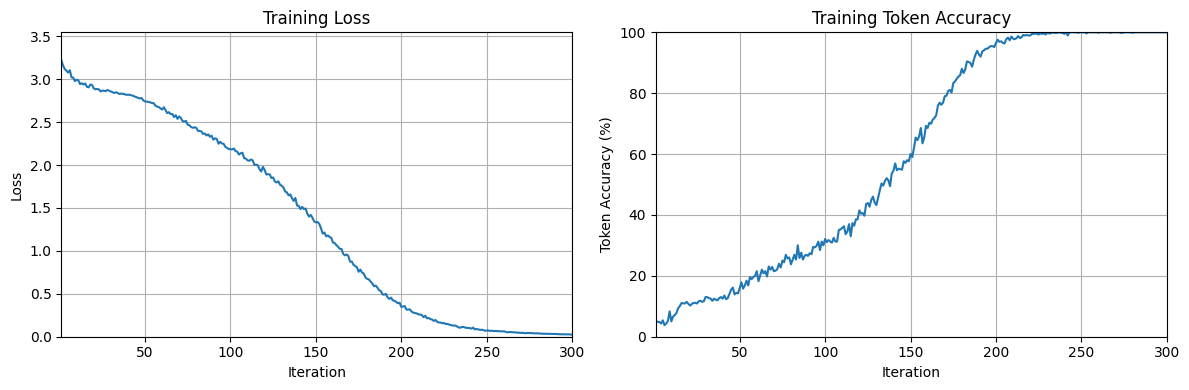

In [ ]:
iters = range(1, num_iters + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax[0].plot(iters, loss_history)
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Loss")
ax[0].set_title("Training Loss")
ax[0].set_xlim(1, num_iters)
ax[0].set_ylim(0, max(loss_history)*1.1)
ax[0].grid(True)

# Accuracy plot
ax[1].plot(iters, tok_acc_history)
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Token Accuracy (%)")
ax[1].set_title("Training Token Accuracy")
ax[1].set_xlim(1, num_iters)
ax[1].set_ylim(0, 100)
ax[1].grid(True)

plt.tight_layout()
plt.show()

Validation:

In [ ]:
transformer.eval()
with tc.no_grad():
    src_data, tgt_in_data, tgt_out_data = make_copy_batch(
        batch_size=256,
        seq_len=seq_len,
        vocab_size=src_vocab_size,
        device=device
    )

    output = transformer(src_data, tgt_in_data)
    pred_tokens = output.argmax(dim=-1)

    tok_acc = (pred_tokens == tgt_out_data).float().mean()

print(f"Validation token accuracy: {100*tok_acc.item():.2f}%")

Validation token accuracy: 100.00%


## <u>Optional Homework</u>

1. **Masking Experiment**  
   Change/remove the target mask and observe how the decoder behavior changes during training. Is the mask necessary?

2. **Attention Visualization**  
   Visualize the attention weights.

3. **Sequence Sorting Task**  
   Modify the dataset so that the Transformer receives a sequence of integers and must output the **sorted sequence**.  
   Example: input `[7, 2, 5, 3]` → output `[2, 3, 5, 7]`  
   Try to train the model on this task.

## <u>References</u>

+ Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. (2017).  
  *Attention Is All You Need.*  
  Advances in Neural Information Processing Systems (NeurIPS).  
  https://arxiv.org/abs/1706.03762

+ PyTorch Documentation – Transformer module:  
  https://pytorch.org/docs/stable/generated/torch.nn.Transformer.html

+ PyTorch Documentation – Multihead Attention:  
  https://pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html

+ PyTorch Tutorials – Sequence-to-Sequence modeling with attention:  
  https://pytorch.org/tutorials/

+ The Annotated Transformer (Harvard NLP):  
  https://nlp.seas.harvard.edu/annotated-transformer/

+ Dive into Deep Learning – Attention and Transformers:  
  https://d2l.ai/chapter_attention-mechanisms/